# Layer 1 Validation Experiments

Validates four assumptions before investing in Layer 2 model improvements.
See `docs/plans/2026-03-09-layer1-validation-design.md` for the full design.

## Setup

In [1]:
import sys
from pathlib import Path

# Navigate to model/ root so all relative paths work consistently
_nb_dir = Path.cwd()
_model_dir = _nb_dir
while _model_dir.name != 'model' and _model_dir != _model_dir.parent:
    _model_dir = _model_dir.parent
if _model_dir.name == 'model':
    get_ipython().run_line_magic('cd', str(_model_dir))

sys.path.insert(0, 'src') if 'src' not in sys.path else None

import json
import logging

import jsonlines
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import pytorch_lightning as pl

pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision("medium")
logging.basicConfig(level=logging.INFO)

from model_improvement.audio_encoders import MuQLoRAModel
from model_improvement.taxonomy import DIMENSIONS, load_composite_labels
from model_improvement.layer1_validation import (
    score_competition_segments,
    competition_correlation,
    dynamic_range_analysis,
)

DATA_DIR = Path("data")
CHECKPOINT_DIR = DATA_DIR / "checkpoints/model_improvement"
COMPETITION_DIR = DATA_DIR / "competition_cache/chopin2021"
PERCEPIANO_DIR = DATA_DIR / "percepiano_cache"

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"CHECKPOINT_DIR: {CHECKPOINT_DIR.resolve()}")

/Users/jdhiman/Documents/crescendai/model


Seed set to 42


DATA_DIR: /Users/jdhiman/Documents/crescendai/model/data
CHECKPOINT_DIR: /Users/jdhiman/Documents/crescendai/model/data/checkpoints/model_improvement


/Users/jdhiman/Documents/crescendai/model/.venv/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


## Experiment 1: Competition Correlation

**Question:** Does A1's quality signal predict expert competition placement?

**Data:** 2,293 segments from Chopin 2021 (already on GDrive, synced locally).

**Decision gate:** rho > 0.3 on at least one aggregation = model signal is real.

In [2]:
# Load A1 fold 3 checkpoint
a1_ckpt = sorted(CHECKPOINT_DIR.glob("A1/fold_3/*.ckpt"))[0]
print(f"Loading A1 from {a1_ckpt.name}")

a1_model = MuQLoRAModel.load_from_checkpoint(
    str(a1_ckpt),
    use_pretrained_muq=False,
)
a1_model.eval()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
a1_model = a1_model.to(device)

# Competition embeddings loaded lazily (one at a time) by score_competition_segments
emb_dir = COMPETITION_DIR / "muq_embeddings"
print(f"Embedding directory: {emb_dir} ({len(list(emb_dir.glob('*.pt')))} files)")

# Load metadata
with jsonlines.open(COMPETITION_DIR / "metadata.jsonl") as reader:
    metadata = list(reader)
print(f"Loaded {len(metadata)} metadata records")
print(f"Performers: {len(set(m['performer'] for m in metadata))}")
print(f"Rounds: {sorted(set(m['round'] for m in metadata))}")

Loading A1 from epoch=5-val_loss=0.5450.ckpt
Embedding directory: data/competition_cache/chopin2021/muq_embeddings (2293 files)
Loaded 2293 metadata records
Performers: 11
Rounds: ['final', 'stage2', 'stage3']


In [3]:
# Score all segments (lazy loading from directory -- ~1.4MB peak per iteration)
segment_scores = score_competition_segments(a1_model, emb_dir)
print(f"Scored {len(segment_scores)} segments")

# Compute correlations
corr_results = competition_correlation(segment_scores, metadata)

# Display results
print("\n=== Competition Correlation Results ===\n")
for agg_name, corr in corr_results.items():
    gate = "PASS" if abs(corr["rho"]) > 0.3 else "INVESTIGATE" if abs(corr["rho"]) > 0.2 else "FAIL"
    print(f"{agg_name:>8s}: rho={corr['rho']:+.3f}  p={corr['p_value']:.4f}  n={corr['n_performers']}  [{gate}]")
    for dim_name, dim_corr in corr["per_dimension"].items():
        print(f"           {dim_name:>14s}: rho={dim_corr['rho']:+.3f}  p={dim_corr['p_value']:.4f}")
    print()

INFO:model_improvement.layer1_validation:Scored 500 segments so far
INFO:model_improvement.layer1_validation:Scored 1000 segments so far
INFO:model_improvement.layer1_validation:Scored 1500 segments so far
INFO:model_improvement.layer1_validation:Scored 2000 segments so far
INFO:model_improvement.layer1_validation:Scored 2293 segments total


Scored 2293 segments

=== Competition Correlation Results ===

    mean: rho=+0.704  p=0.0156  n=11  [PASS]
                 dynamics: rho=-0.917  p=0.0001
                   timing: rho=-0.590  p=0.0561
                 pedaling: rho=+0.887  p=0.0003
             articulation: rho=+0.292  p=0.3828
                 phrasing: rho=+0.803  p=0.0029
           interpretation: rho=+0.169  p=0.6204

  median: rho=+0.248  p=0.4625  n=11  [INVESTIGATE]
                 dynamics: rho=-0.615  p=0.0442
                   timing: rho=-0.788  p=0.0040
                 pedaling: rho=+0.853  p=0.0009
             articulation: rho=+0.258  p=0.4441
                 phrasing: rho=+0.758  p=0.0068
           interpretation: rho=-0.183  p=0.5893

     min: rho=+0.654  p=0.0289  n=11  [PASS]
                 dynamics: rho=+0.773  p=0.0052
                   timing: rho=+0.431  p=0.1854
                 pedaling: rho=+0.644  p=0.0323
             articulation: rho=+0.520  p=0.1007
                 phrasing

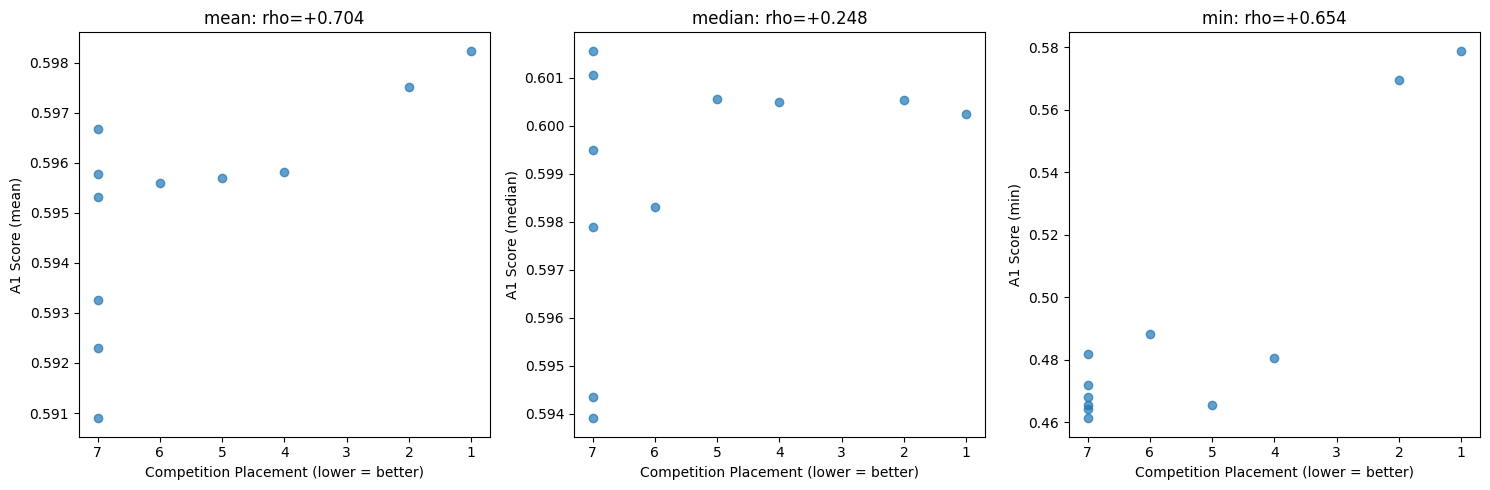

In [4]:
# Scatter plots: per-aggregation, overall score vs placement
from collections import defaultdict

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, agg_name in zip(axes, ["mean", "median", "min"]):
    perf_segs = defaultdict(list)
    perf_place = {}
    for m in metadata:
        if m["segment_id"] in segment_scores:
            perf_segs[m["performer"]].append(segment_scores[m["segment_id"]])
            perf_place[m["performer"]] = m["placement"]

    agg_fn = {"mean": np.mean, "median": np.median, "min": np.min}[agg_name]
    performers = sorted(perf_segs.keys())
    agg_overall = [agg_fn(perf_segs[p], axis=0).mean() for p in performers]
    placements = [perf_place[p] for p in performers]

    ax.scatter(placements, agg_overall, alpha=0.7)
    ax.set_xlabel("Competition Placement (lower = better)")
    ax.set_ylabel(f"A1 Score ({agg_name})")
    ax.set_title(f"{agg_name}: rho={corr_results[agg_name]['rho']:+.3f}")
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig(COMPETITION_DIR / "correlation_scatter.png", dpi=150)
plt.show()

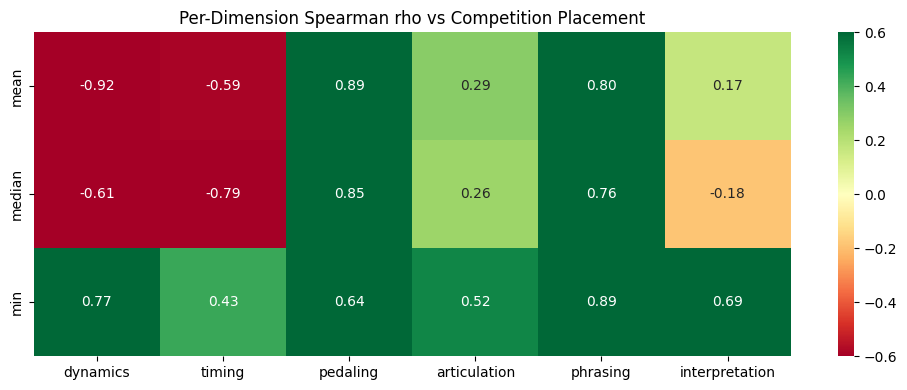

In [5]:
# Per-dimension correlation heatmap
fig, ax = plt.subplots(figsize=(10, 4))
data = []
for agg_name in ["mean", "median", "min"]:
    row = [corr_results[agg_name]["per_dimension"][d]["rho"] for d in DIMENSIONS]
    data.append(row)

sns.heatmap(
    np.array(data), annot=True, fmt=".2f", cmap="RdYlGn",
    xticklabels=DIMENSIONS, yticklabels=["mean", "median", "min"],
    ax=ax, center=0, vmin=-0.6, vmax=0.6,
)
ax.set_title("Per-Dimension Spearman rho vs Competition Placement")
plt.tight_layout()
plt.savefig(COMPETITION_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

## Experiment 3: Dynamic Range at Intermediate Level

**Question:** Does A1 produce meaningful score variance on intermediate-level recordings?

**Data:** YouTube recordings of intermediate pianists.
Must be collected first using yt-dlp (manual search for student recitals).

**No hard gate.** Diagnostic only -- informs Layer 3 data priorities.

In [ ]:
# Intermediate recordings: search, download, and embed.
# Step 1: Run the curation script to find candidates:
#   python scripts/curate_intermediate_recordings.py
# Step 2: Review candidates.jsonl, add "approved": true to selected entries
# Step 3: Download and embed approved recordings:
#   python scripts/curate_intermediate_recordings.py --download
#
# This cell checks for existing embeddings and reports status.

INTERMEDIATE_DIR = DATA_DIR / "intermediate_cache"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
INTERMEDIATE_EMB = INTERMEDIATE_DIR / "muq_embeddings"
INTERMEDIATE_EMB.mkdir(parents=True, exist_ok=True)

n_emb = len(list(INTERMEDIATE_EMB.glob("*.pt")))
candidates_path = INTERMEDIATE_DIR / "candidates.jsonl"

if n_emb > 0:
    print(f"Intermediate embeddings: {n_emb} files (ready for scoring)")
elif candidates_path.exists():
    import jsonlines as _jl
    with _jl.open(candidates_path) as reader:
        candidates = list(reader)
    n_approved = sum(1 for c in candidates if c.get("approved"))
    print(f"Candidates found: {len(candidates)} total, {n_approved} approved")
    if n_approved == 0:
        print("Edit candidates.jsonl to approve recordings, then run:")
        print("  python scripts/curate_intermediate_recordings.py --download")
    else:
        print("Run: python scripts/curate_intermediate_recordings.py --download")
else:
    print("No intermediate data yet. Run:")
    print("  python scripts/curate_intermediate_recordings.py")
    print("Then review candidates.jsonl and approve entries.")

In [7]:
# Score intermediate segments with A1 (lazy loading from directory)
if list(INTERMEDIATE_EMB.glob("*.pt")):
    int_scores = score_competition_segments(a1_model, INTERMEDIATE_EMB)
else:
    int_scores = {}
    print("No intermediate data yet. Populate INTERMEDIATE_URLS and re-run the download cell.")

# Load PercePiano scores for comparison (advanced reference)
labels = load_composite_labels(DATA_DIR / "composite_labels/composite_labels.json")
percepiano_scores = {k: np.array(v[:6]) for k, v in labels.items()}

# Compare distributions
if int_scores:
    groups = {
        "intermediate": int_scores,
        "advanced (PercePiano)": percepiano_scores,
    }
    groups["professional (Chopin 2021)"] = segment_scores

    range_results = dynamic_range_analysis(groups)

    print("\n=== Dynamic Range Analysis ===")
    for group, stats in range_results["group_stats"].items():
        print(f"{group}: mean={stats['overall_mean']:.3f}, std={stats['overall_std']:.3f}, n={stats['n_segments']}")
    print()
    for key, sep in range_results["separation"].items():
        if isinstance(sep, dict):
            print(f"  {key}: diff={sep['mean_diff']:+.3f}, Cohen's d={sep['cohens_d']:.2f}")

No intermediate data yet. Populate INTERMEDIATE_URLS and re-run the download cell.


In [8]:
if int_scores:
    import pandas as pd

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for d, (ax, dim_name) in enumerate(zip(axes, DIMENSIONS)):
        plot_data = []
        group_labels = []
        for group_name, scores_dict in groups.items():
            vals = [s[d] for s in scores_dict.values()]
            plot_data.extend(vals)
            group_labels.extend([group_name] * len(vals))

        df = pd.DataFrame({"Score": plot_data, "Group": group_labels})
        sns.boxplot(data=df, x="Group", y="Score", ax=ax)
        ax.set_title(dim_name)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

    plt.suptitle("Per-Dimension Score Distributions by Skill Level")
    plt.tight_layout()
    plt.savefig(INTERMEDIATE_DIR / "dynamic_range_boxplots.png", dpi=150)
    plt.show()
else:
    print("Skipping box plots -- no intermediate data available yet.")

Skipping box plots -- no intermediate data available yet.


## Experiment 2: AMT Degradation Test

**Question:** How much does S2's pairwise accuracy drop with transcribed MIDI vs ground-truth?

**Data:** 50 MAESTRO recordings with ground-truth MIDI. Transcribed with YourMT3+ (ceiling) and ByteDance (floor).

**Decision gate:** Per-dimension pairwise drop < 10% = symbolic path viable.

**Note:** This experiment requires installing YourMT3+ and ByteDance Piano Transcription.
AMT transcription takes ~4-8 hours on M4. Run the transcription cells once,
then the assessment cells reuse cached transcriptions.

In [ ]:
with open(DATA_DIR / "maestro_cache/contrastive_mapping.json") as f:
    contrastive_mapping = json.load(f)

from model_improvement.layer1_validation import select_maestro_subset
selected_keys = select_maestro_subset(contrastive_mapping, n_recordings=50)
print(f"Selected {len(selected_keys)} unique recordings from {len(contrastive_mapping)} pieces")
print(f"Sample keys: {selected_keys[:3]}")

In [ ]:
# AMT transcription -- run once, results are cached.
# Prerequisites:
#   1. Download MAESTRO audio: python scripts/download_maestro_subset.py
#   2. Install ByteDance: uv pip install piano-transcription-inference
#   3. Install YourMT3+: uv pip install git+https://github.com/mimbres/YourMT3.git
#
# This cell is expensive (~4-8 hours on M4). Skip if transcriptions already exist.

from model_improvement.maestro import parse_maestro_audio_metadata

AMT_DIR = DATA_DIR / "amt_cache"
AMT_DIR.mkdir(parents=True, exist_ok=True)
YOURMT3_DIR = AMT_DIR / "yourmt3"
YOURMT3_DIR.mkdir(parents=True, exist_ok=True)
BYTEDANCE_DIR = AMT_DIR / "bytedance"
BYTEDANCE_DIR.mkdir(parents=True, exist_ok=True)

MAESTRO_DIR = DATA_DIR / "maestro_cache"

# Map selected segment IDs back to unique audio filenames
maestro_records = parse_maestro_audio_metadata(MAESTRO_DIR)

def _segment_id_to_audio_filename(seg_id, records):
    body = seg_id
    if body.startswith("maestro_"):
        body = body[len("maestro_"):]
    seg_idx = body.rfind("_seg")
    if seg_idx >= 0:
        body = body[:seg_idx]
    for rec in records:
        normalized = rec["audio_filename"].replace("/", "_").replace(".", "_")
        if normalized == body:
            return rec
    return None

selected_audio = {}
for seg_id in selected_keys:
    rec = _segment_id_to_audio_filename(seg_id, maestro_records)
    if rec:
        selected_audio[rec["audio_filename"]] = rec

audio_files = sorted(selected_audio.keys())
print(f"Selected {len(audio_files)} unique audio files for AMT")

# Check which audio files exist
existing = [af for af in audio_files if (MAESTRO_DIR / af).exists()]
missing = [af for af in audio_files if not (MAESTRO_DIR / af).exists()]
print(f"Audio files on disk: {len(existing)} / {len(audio_files)}")

if missing:
    print(f"\nMissing {len(missing)} audio files. Download with:")
    print("  python scripts/download_maestro_subset.py")
elif existing:
    # ByteDance transcription
    n_bytedance_existing = len(list(BYTEDANCE_DIR.glob("*.mid")))
    if n_bytedance_existing >= len(existing):
        print(f"\nByteDance transcriptions: {n_bytedance_existing} (cached)")
    else:
        print(f"\nRunning ByteDance transcription ({len(existing)} files)...")
        from piano_transcription_inference import PianoTranscription
        transcriptor = PianoTranscription(device="cpu")
        for i, af in enumerate(existing):
            recording_id = af.replace("/", "_").replace(".wav", "")
            out_path = BYTEDANCE_DIR / f"{recording_id}.mid"
            if out_path.exists():
                continue
            audio_path = str(MAESTRO_DIR / af)
            print(f"  [{i+1}/{len(existing)}] {af}")
            transcriptor.transcribe(audio_path, str(out_path))
        del transcriptor
        print(f"  ByteDance done: {len(list(BYTEDANCE_DIR.glob('*.mid')))} files")

    # YourMT3+ transcription
    n_yourmt3_existing = len(list(YOURMT3_DIR.glob("*.mid")))
    if n_yourmt3_existing >= len(existing):
        print(f"YourMT3+ transcriptions: {n_yourmt3_existing} (cached)")
    else:
        try:
            from yourmt3.transcribe import transcribe_audio
            print(f"\nRunning YourMT3+ transcription ({len(existing)} files)...")
            for i, af in enumerate(existing):
                recording_id = af.replace("/", "_").replace(".wav", "")
                out_path = YOURMT3_DIR / f"{recording_id}.mid"
                if out_path.exists():
                    continue
                audio_path = str(MAESTRO_DIR / af)
                print(f"  [{i+1}/{len(existing)}] {af}")
                transcribe_audio(audio_path, str(out_path))
            print(f"  YourMT3+ done: {len(list(YOURMT3_DIR.glob('*.mid')))} files")
        except ImportError:
            print("\nYourMT3+ not installed. Install with:")
            print("  uv pip install git+https://github.com/mimbres/YourMT3.git")
            print("Continuing with ByteDance only.")

In [ ]:
# S2 pairwise assessment: ground-truth vs AMT-transcribed MIDI
from model_improvement.symbolic_encoders import GNNSymbolicEncoder
from model_improvement.graph import midi_to_graph
from model_improvement.layer1_validation import amt_degradation_comparison

s2_ckpt = sorted(CHECKPOINT_DIR.glob("S2/fold_3/*.ckpt"))[0]
print(f"Loading S2 from {s2_ckpt.name}")

s2_model = GNNSymbolicEncoder.load_from_checkpoint(str(s2_ckpt))
s2_model.eval()
s2_model.cpu()

def score_midi_files(model, midi_dir, recording_ids):
    """Score MIDI files with S2, returning {recording_id: scores [6]}."""
    results = {}
    with torch.no_grad():
        for rid in recording_ids:
            midi_path = midi_dir / f"{rid}.mid"
            if not midi_path.exists():
                midi_path = midi_dir / f"{rid}.midi"
            if not midi_path.exists():
                continue
            try:
                graph = midi_to_graph(midi_path)
            except (ValueError, Exception) as e:
                print(f"  Skipping {rid}: {e}")
                continue
            out = model(graph.x, graph.edge_index, torch.zeros(graph.x.size(0), dtype=torch.long))
            results[rid] = out["scores"].squeeze(0).numpy()
    return results

# Build recording IDs from selected audio files
recording_ids = [af.replace("/", "_").replace(".wav", "") for af in audio_files]

# Check what MIDI sources are available
sources = {}

# Ground truth: MAESTRO MIDI files
gt_scores = {}
with torch.no_grad():
    for af in audio_files:
        rec = selected_audio[af]
        midi_file = rec.get("midi_filename", "")
        midi_path = MAESTRO_DIR / midi_file
        rid = af.replace("/", "_").replace(".wav", "")
        if not midi_path.exists():
            continue
        try:
            graph = midi_to_graph(midi_path)
        except (ValueError, Exception) as e:
            print(f"  Skipping GT {rid}: {e}")
            continue
        out = s2_model(graph.x, graph.edge_index, torch.zeros(graph.x.size(0), dtype=torch.long))
        gt_scores[rid] = out["scores"].squeeze(0).numpy()

if gt_scores:
    sources["ground_truth"] = gt_scores
    print(f"Ground truth: scored {len(gt_scores)} recordings")

# ByteDance transcriptions
if list(BYTEDANCE_DIR.glob("*.mid")):
    bd_scores = score_midi_files(s2_model, BYTEDANCE_DIR, recording_ids)
    if bd_scores:
        sources["bytedance"] = bd_scores
        print(f"ByteDance: scored {len(bd_scores)} recordings")

# YourMT3+ transcriptions
if list(YOURMT3_DIR.glob("*.mid")):
    ym_scores = score_midi_files(s2_model, YOURMT3_DIR, recording_ids)
    if ym_scores:
        sources["yourmt3"] = ym_scores
        print(f"YourMT3+: scored {len(ym_scores)} recordings")

# Pairwise assessment
if len(sources) >= 2 and "ground_truth" in sources:
    # For each source, compute pairwise accuracy on contrastive pairs
    # Group recordings by piece for pairwise comparison
    piece_recordings = {}
    for af in audio_files:
        rec = selected_audio[af]
        title = rec["canonical_title"]
        rid = af.replace("/", "_").replace(".wav", "")
        if title not in piece_recordings:
            piece_recordings[title] = []
        piece_recordings[title].append(rid)

    # Only pieces with 2+ recordings
    contrastive_pieces = {p: rids for p, rids in piece_recordings.items() if len(rids) >= 2}
    print(f"\nContrastive pieces: {len(contrastive_pieces)}")

    pairwise_results = {}
    for source_name, scores_dict in sources.items():
        correct = np.zeros(6)
        total = np.zeros(6)
        overall_correct = 0
        overall_total = 0

        for piece, rids in contrastive_pieces.items():
            for i in range(len(rids)):
                for j in range(i + 1, len(rids)):
                    r_a, r_b = rids[i], rids[j]
                    if r_a not in scores_dict or r_b not in scores_dict:
                        continue
                    s_a = scores_dict[r_a]
                    s_b = scores_dict[r_b]
                    # Use ground truth ranking as reference
                    if r_a not in gt_scores or r_b not in gt_scores:
                        continue
                    gt_a = gt_scores[r_a].mean()
                    gt_b = gt_scores[r_b].mean()
                    if abs(gt_a - gt_b) < 0.01:
                        continue  # Skip ambiguous pairs

                    pred_diff = s_a - s_b
                    gt_sign = 1 if gt_a > gt_b else -1

                    for d in range(6):
                        total[d] += 1
                        if (pred_diff[d] > 0 and gt_sign > 0) or (pred_diff[d] < 0 and gt_sign < 0):
                            correct[d] += 1

                    overall_total += 1
                    pred_overall = s_a.mean() - s_b.mean()
                    if (pred_overall > 0 and gt_sign > 0) or (pred_overall < 0 and gt_sign < 0):
                        overall_correct += 1

        if overall_total > 0:
            pairwise_results[source_name] = {
                "overall": overall_correct / overall_total,
                "per_dimension": {d: (correct[d] / total[d] if total[d] > 0 else 0.0) for d in range(6)},
                "n_pairs": int(overall_total),
            }
            print(f"\n{source_name}: {overall_correct}/{overall_total} = {overall_correct/overall_total:.1%} pairwise accuracy")

    if len(pairwise_results) >= 2:
        degradation = amt_degradation_comparison(pairwise_results, baseline="ground_truth")
        print("\n=== AMT Degradation Results ===")
        for source, drops in degradation.items():
            gate = "PASS" if drops["viable"] else "FAIL"
            print(f"\n{source}: overall drop = {drops['overall_drop_pct']:+.1f}% [{gate}]")
            for dim_name, drop in drops["per_dimension_drop_pct"].items():
                print(f"  {dim_name:>14s}: {drop:+.1f}%")
    else:
        print("\nNeed at least ground_truth + one AMT source for degradation comparison.")
else:
    print("\nAMT assessment requires ground-truth + at least one transcription source.")
    if not sources:
        print("No MIDI scores computed. Download MAESTRO audio and run transcription first.")